# MES Bollinger-squeeze / VWAP breakout, 15-minute bars (Tradovate exchange)

Re-run of `bollinger_vwap_breakout_mes.ipynb` (5-minute bars, direction=both,
narrow grid: `bb_length`∈{20,30}×`squeeze_percentile`∈{0.10,0.20}) which found
every combo net-negative and two of four breaching the drawdown middleware,
plus a follow-up EMA trend filter that didn't help. This pass applies the same
long-only+15m fix that rescued Donchian/Keltner/SuperTrend, widens the
parameter grid substantially, and directly compares `direction=both` against
`direction=long` and `direction=short` on the best combo -- the original
5-minute pass never tried anything but `both`.

**Mechanism unchanged** (`BollingerVwapBreakoutStrategy`): enters the moment
Bollinger Bands are in a "squeeze" (band width at/below a rolling percentile
threshold), direction decided by price's position relative to session VWAP.
Stop at the opposite band, take-profit at a fixed R:R of that risk.

Same discipline as every other notebook in this pipeline: naive full-history
grid -> best-combo detailed report -> direction comparison -> 75/25 holdout ->
(if promising) walk-forward, on real Databento MES 1-minute data resampled to
15-minute bars.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerVwapBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Grid search: BB length x squeeze percentile, direction=both

Substantially wider than the original 5-minute pass's `bb_length`∈{20,30}×
`squeeze_percentile`∈{0.10,0.20} -- `bb_length`∈{10,20,30,50} (added a faster
10-bar option and a slower 50-bar one) x `squeeze_percentile`∈{0.05,0.10,0.20,
0.30} (added a tighter 5th-percentile squeeze and a looser 30th-percentile
one). `bb_std_dev=2.0`, `squeeze_lookback=100` bars (~25 hours on 15m bars),
and `risk_reward_ratio=2.0` fixed, same as the original pass -- grid the core
two parameters, fix the extras, same convention as every notebook in this
pipeline. `direction=both` for this first pass, matching the original;
long-only/short-only comparison follows once the best combo is found.


In [3]:
BB_STD_DEV = 2.0
SQUEEZE_LOOKBACK = 100
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
SQUEEZE_PERCENTILE_CANDIDATES = [0.05, 0.10, 0.20, 0.30]
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def build_squeeze_indicators(bb_length: int, squeeze_percentile: float):
    lower, middle, upper = Indicators.bollinger_bands(ohlc, length=bb_length, std_dev=BB_STD_DEV)
    width = (upper - lower) / middle
    threshold = width.rolling(SQUEEZE_LOOKBACK).quantile(squeeze_percentile)
    is_squeeze = width <= threshold
    return lower, upper, is_squeeze


def run_breakout_backtest(ohlc_slice: pd.DataFrame, bb_length: int, squeeze_percentile: float, key: str,
                           direction: StrategyDirection = StrategyDirection.both):
    lower, middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=BB_STD_DEV)
    width = (upper - lower) / middle
    threshold = width.rolling(SQUEEZE_LOOKBACK).quantile(squeeze_percentile)
    is_squeeze = width <= threshold
    vwap, _vwap_std = Indicators.vwap_session(ohlc_slice)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="vwap", df=vwap)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="is_squeeze", df=is_squeeze)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerVwapBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, vwap_indicator_key="vwap",
            bb_lower_key="bb_lower", bb_upper_key="bb_upper", squeeze_indicator_key="is_squeeze",
            risk_reward_ratio=RISK_REWARD_RATIO, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for squeeze_percentile in SQUEEZE_PERCENTILE_CANDIDATES:
        bt, drawdown_mw = run_breakout_backtest(ohlc, bb_length, squeeze_percentile,
                                                  key=f"BVB_both_{bb_length}_{squeeze_percentile}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(bb_length, squeeze_percentile)] = (bt, drawdown_mw)
        grid_rows.append({
            "bb_length": bb_length, "squeeze_percentile": squeeze_percentile,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\ngrid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


bb_length=10 done, 137s elapsed


bb_length=20 done, 222s elapsed


bb_length=30 done, 291s elapsed


bb_length=50 done, 341s elapsed



grid done in 341s

    bb_length  squeeze_percentile  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          50                0.20            4.810880      0.095641              -21.3843         1547.0            214.9         35.294118       1.108724               0.062657              1.040738           4.999923         5354.44           False
1          50                0.10            0.073958      0.037670              -18.5641         1403.0            194.9         36.136850       1.092325               0.087503              1.032408           3.447675         4813.90           False
2          50                0.05           -0.979095      0.017430              -19.3648         1221.0            169.6         35.217035       1.073087               0.059725              1.029131           3.055133         

### Heatmaps: Sharpe ratio and net return across (bb_length, squeeze_percentile)


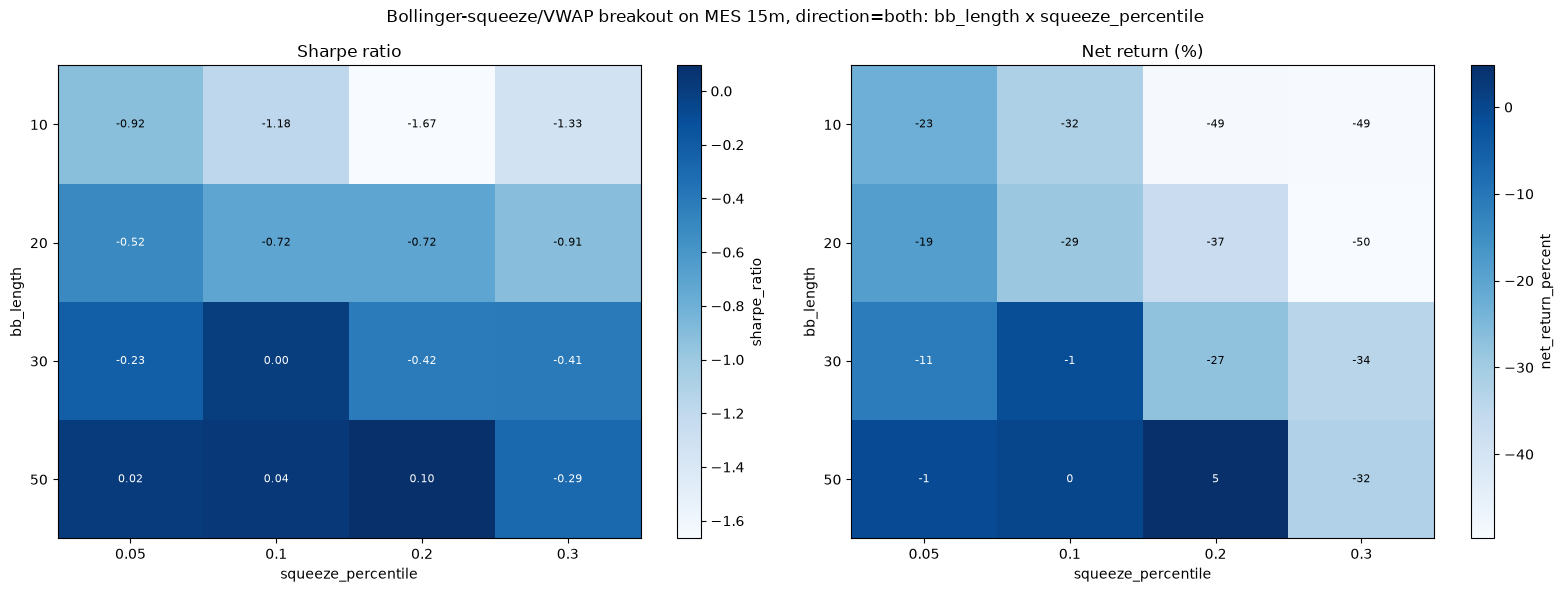

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("squeeze_percentile")
    ax.set_ylabel("bb_length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="bb_length", columns="squeeze_percentile", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="bb_length", columns="squeeze_percentile", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger-squeeze/VWAP breakout on MES 15m, direction=both: bb_length x squeeze_percentile")
fig.tight_layout()
plt.show()


## Detailed report for the best (both-direction) combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, squeeze_percentile) combo from the grid above.


Best combo: bb_length=50, squeeze_percentile=0.2
Candles Processed: 168277
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.0956,0.8453,0.0507,1.6044,-0.8696,1.1256,-1.9146,-0.2437,1.2735,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.1382,1.2257,0.0717,2.5462,-1.2584,1.7737,-2.4481,-0.3612,1.9816,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,8.4318,7.0903,15.6379,5.3794,10.0245,5.2900,3.7717,6.5255,5.9805,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,0.6555,8.6725,-0.6203,13.1155,-12.5316,8.8115,-10.0509,-2.5836,11.4368,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.0307,1.4713,-0.0387,4.1204,-0.7897,3.5154,-0.8723,-0.3674,3.5002,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,0.2250,0.9536,-0.0387,4.1084,-0.7877,3.5053,-0.8723,-0.3664,1.7939,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-21.3843,-5.8943,-16.0130,-3.1831,-15.8680,-2.5066,-11.5223,-7.0313,-3.2675,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1477,132,276,88,188,96,334,268,84,719,How long it took to recover the loss. Shorter is better.
ulcer_index,11.8694,2.9811,9.8859,1.1412,7.5827,1.0791,8.3985,3.2828,1.4799,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.6985,-0.5767,-1.5078,-0.5218,-0.9725,-0.4932,-0.4488,-0.5382,-0.5974,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


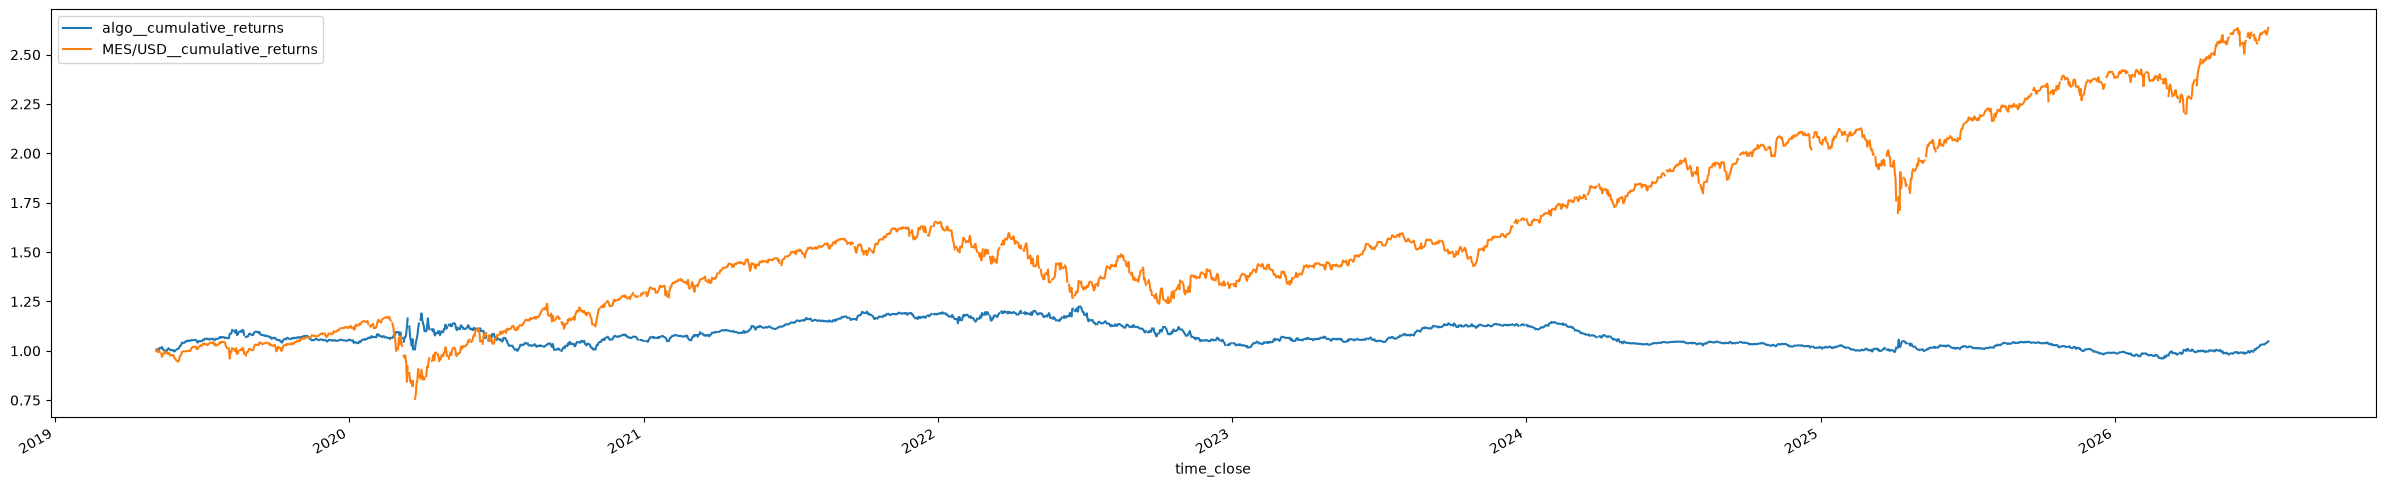

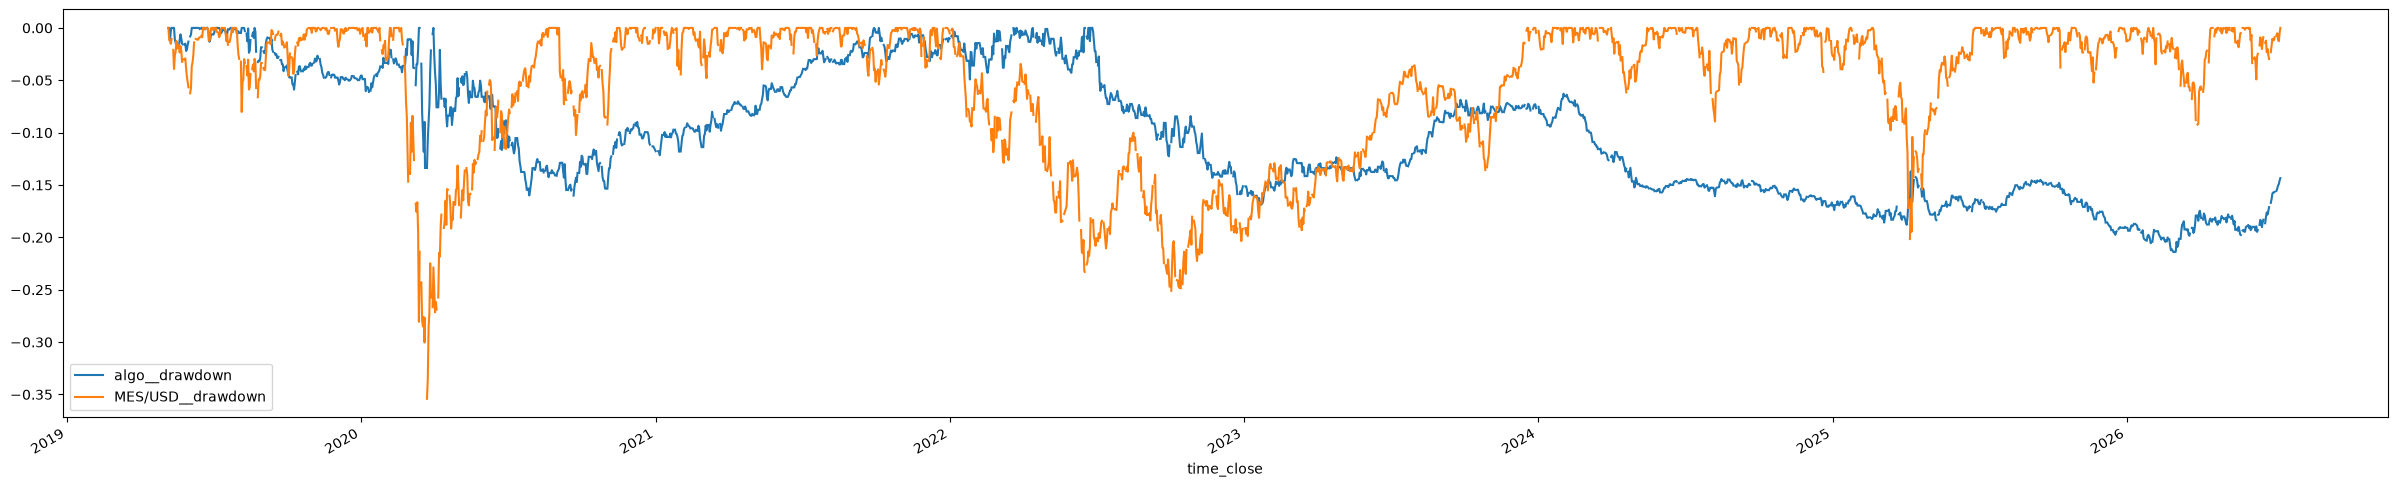

In [5]:
best_bb_length, best_squeeze_pct = grid_results.iloc[0][["bb_length", "squeeze_percentile"]]
best_bb_length = int(best_bb_length)
best_squeeze_pct = float(best_squeeze_pct)
print(f"Best combo: bb_length={best_bb_length}, squeeze_percentile={best_squeeze_pct}")
best_backtest, best_drawdown_mw = grid_backtests[(best_bb_length, best_squeeze_pct)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

The original 5-minute pass only ever tried `direction=both`. Holding
(bb_length, squeeze_percentile) fixed at the best both-direction combo above,
re-runs with `direction=long` and `direction=short` to see whether either side
alone carries the (or a better) edge -- same question this pipeline asked of
Donchian early on, where the answer was "long-only, decisively."


In [6]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_breakout_backtest(ohlc, best_bb_length, best_squeeze_pct,
                                              key=f"BVB_dir_{direction.value}", direction=direction)
    summary = bt.reporter.summary["algo"]
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({
        "direction": direction.value,
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"], "profit_factor": summary["profit_factor"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "account_failed": drawdown_mw.account_failed,
    })

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  profit_factor  dollar_profit_factor  dollar_expectancy  account_failed
direction                                                                                                                                                                 
both                 4.810880      0.095641              -21.3843         1547.0         35.294118       1.108724              1.040738           4.999923           False
long                25.249667      0.300560              -17.0811         1432.0         35.754190       1.141780              1.099772          12.992777           False
short              -38.950581     -0.681967              -44.9197         1498.0         31.975968       0.938230              0.851217         -12.382391           False


## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [7]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_breakout_backtest(ohlc_slice, best_bb_length, best_squeeze_pct,
                                              key=f"BVB_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       1432         35.754190      0.046555         0.003061        0.300560           25.249667              1.099772          12.992777              -17.0811           False
TRAIN (75%)                1075         36.558140      0.061563         0.011344        0.446140           32.865229              1.146655          20.040847              -17.0811           False
TEST (last 25%, unseen)     355         33.521127     -0.007347        -0.094656       -0.280126           -3.634282              0.957757          -3.284329               -9.9253           False


## Findings

**The long-only + 15m fix rescues this mechanism too -- the first promising
result for Bollinger-squeeze/VWAP breakout anywhere in this pipeline.** The
original 5-minute/both-direction pass was net-negative across its whole grid
(-41% to -50%, two combos breaching the drawdown middleware). On 15-minute
bars with a wider grid, the picture is much better, though still marginal at
the both-direction level.

**Grid** (`bb_length`∈{10,20,30,50}×`squeeze_percentile`∈{0.05,0.10,0.20,
0.30}, direction=both): best combo (`bb_length=50, squeeze_percentile=0.20`)
is only weakly positive full-history (net +4.8%, Sharpe 0.096,
`dollar_profit_factor` 1.04) -- better than the 5-minute pass but not
compelling on its own. **`bb_length=50` sits at the edge of the grid** (the
widest candidate tried), the same "still improving at the boundary" signal
that has motivated widening a grid in this pipeline before.

**Direction comparison on that combo is where the real signal shows up**:

| direction | net_return | sharpe | dollar_profit_factor | max_drawdown |
|---|---|---|---|---|
| both | +4.8% | 0.096 | 1.041 | -21.4% |
| **long** | **+25.2%** | **0.301** | **1.100** | **-17.1%** |
| short | -39.0% | -0.682 | 0.851 | -44.9% |

Long-only more than doubles both-direction's Sharpe and cuts max drawdown;
short-only is decisively bad (fighting the same long-only trend edge this
whole pipeline keeps finding on MES). This is now the fourth structurally
different mechanism (after Donchian, SuperTrend, Keltner) rescued by the
identical fix -- strong further evidence this is a property of the
instrument/timeframe/direction combination itself, not any one signal's
construction.

**Holdout on the best long-only combo**: TRAIN `trade_sharpe_lb`=+0.0113
(positive), TEST `trade_sharpe_lb`=-0.095 (negative, net -3.6%,
`dollar_profit_factor` 0.958 -- below 1). Same "promising TRAIN, weaker/
negative TEST on a smaller sample" signature every other strategy in this
pipeline showed before walk-forward either confirmed or killed it (355 TEST
trades here, similar scale to MES SuperTrend's TEST sample).

**Bottom line**: this clears the bar for walk-forward -- proceeding now,
widening `bb_length` upward past 50 since the full-history winner sat at the
grid edge (same reasoning used for MNQ Keltner's and MES SuperTrend's
walk-forward grids).

## Walk-forward validation: long-only, 15-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat.

**Grid**: `bb_length` in {30, 50, 75, 100} x `squeeze_percentile` in {0.05,
0.10, 0.20, 0.30} -- widened upward past 50 since the full-history best sat
at the edge of the original {10,20,30,50} grid, same "still improving at the
boundary" signal that motivated widening a grid in this pipeline before.
`direction` fixed at `long` (this pass's own finding), `bb_std_dev=2.0`,
`squeeze_lookback=100`, and `risk_reward_ratio=2.0` fixed. Selection uses the
same trade-Sharpe-lower-bound + 3x3-smoothed-plateau methodology as every
other walk-forward pass.


In [8]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_BB_LENGTH_GRID = [30, 50, 75, 100]
WF_SQUEEZE_PCT_GRID = [0.05, 0.10, 0.20, 0.30]

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [9]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for bb_length in WF_BB_LENGTH_GRID:
        for squeeze_pct in WF_SQUEEZE_PCT_GRID:
            bt, _ = run_breakout_backtest(train_slice, bb_length, squeeze_pct, key=f"wf{step_i}_train_{bb_length}_{squeeze_pct}",
                                            direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"bb_length": bb_length, "squeeze_percentile": squeeze_pct, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_bb_length, chosen_squeeze_pct = WF_BB_LENGTH_GRID[0], WF_SQUEEZE_PCT_GRID[0]
    else:
        try:
            chosen_bb_length, chosen_squeeze_pct = pick_plateau(inner_df, "bb_length", "squeeze_percentile", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_bb_length, chosen_squeeze_pct = best_row["bb_length"], best_row["squeeze_percentile"]

    oos_bt, oos_mw = run_breakout_backtest(test_slice, int(chosen_bb_length), float(chosen_squeeze_pct),
                                             key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_bb_length": int(chosen_bb_length), "chosen_squeeze_pct": float(chosen_squeeze_pct),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(bb_length={int(chosen_bb_length)}, squeeze_pct={chosen_squeeze_pct}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(bb_length=30, squeeze_pct=0.3) oos_trades=157 oos_net_return=2.8%  (34s elapsed)


step 1: chosen(bb_length=100, squeeze_pct=0.3) oos_trades=40 oos_net_return=-7.7%  (73s elapsed)


step 2: chosen(bb_length=30, squeeze_pct=0.3) oos_trades=170 oos_net_return=3.7%  (114s elapsed)


step 3: chosen(bb_length=30, squeeze_pct=0.3) oos_trades=159 oos_net_return=-4.1%  (173s elapsed)


step 4: chosen(bb_length=30, squeeze_pct=0.2) oos_trades=151 oos_net_return=-3.2%  (209s elapsed)


...

step 6: chosen(bb_length=30, squeeze_pct=0.05) oos_trades=96 oos_net_return=-0.5%  (286s elapsed)


step 7: chosen(bb_length=100, squeeze_pct=0.05) oos_trades=35 oos_net_return=-0.6%  (324s elapsed)


step 8: chosen(bb_length=100, squeeze_pct=0.05) oos_trades=46 oos_net_return=4.3%  (362s elapsed)


step 9: chosen(bb_length=100, squeeze_pct=0.3) oos_trades=19 oos_net_return=-1.3%  (402s elapsed)



walk-forward done in 402s

   step train_start  test_start    test_end  chosen_bb_length  chosen_squeeze_pct  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05                30                0.30         157             35.668790            -0.030166                2.751923                  1.209380               False
1     1  2019-11-05  2021-11-05  2022-05-05               100                0.30          40             30.000000            -0.357705               -7.686806                  0.739887               False
2     2  2020-05-05  2022-05-05  2022-11-05                30                0.30         170             34.705882            -0.071280                3.709236                  1.128348               False
3     3  2020-11-05  2022-11-05  2023-05-05                30                0.30         159             32.075472            -0.122640        

### Parameter stability across steps


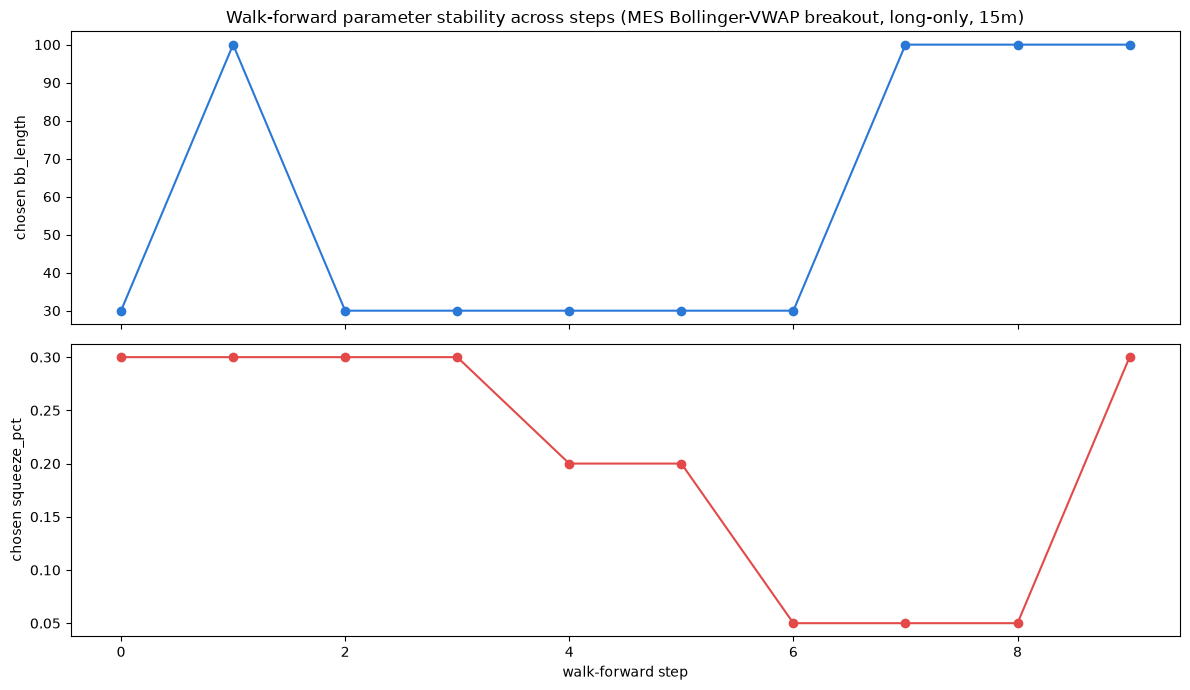

bb_length: unique values chosen = [np.int64(30), np.int64(100)]
squeeze_pct: unique values chosen = [np.float64(0.05), np.float64(0.2), np.float64(0.3)]


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_bb_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen bb_length")
axes[0].set_title("Walk-forward parameter stability across steps (MES Bollinger-VWAP breakout, long-only, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_squeeze_pct"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen squeeze_pct")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"bb_length: unique values chosen = {sorted(wf_results['chosen_bb_length'].unique())}")
print(f"squeeze_pct: unique values chosen = {sorted(wf_results['chosen_squeeze_pct'].unique())}")


### The real track record: concatenated out-of-sample trades


In [11]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 1016
OOS win rate: 33.66%
OOS trade_sharpe: 0.0173
OOS trade_sharpe_lb: -0.0343
OOS sum of trade pnl (frictionless, %): 13.10%


## Walk-forward conclusion

**Negative -- the promising holdout does not survive, joining MES SuperTrend
and MES Keltner in the "looked good on one split, didn't confirm" bucket.**

| metric | value |
|---|---|
| OOS trades | 1,016 |
| OOS win rate | 33.7% |
| OOS `trade_sharpe` (point estimate) | +0.017 |
| OOS `trade_sharpe_lb` | **-0.0343** |
| OOS sum of trade pnl (frictionless) | +13.1% |

Only 3 of 10 steps had a positive OOS net return (0, 2, 8); several were
clearly bad (step 1: -7.7%, `dollar_profit_factor` 0.74; step 9: -1.3% on
just 19 trades). Trade counts per step also shrank steadily over time (157 in
step 0 down to 19 in step 9) as the walk-forward increasingly favored
`bb_length=100` in later steps -- a much slower-firing squeeze condition.

**Parameter selection notably never chose the full-history winner
(`bb_length=50`) even once** -- it split between `bb_length=30` (6/10 steps,
mostly earlier) and `bb_length=100` (4/10 steps, mostly later), with
`squeeze_percentile` spread across 0.05/0.20/0.30 (0.10 never chosen either).
This is more wander than a clean confirmation would show, and it's a
different failure signature from MES SuperTrend's (which wandered across most
of its grid) -- here the walk-forward seems to be tracking a real regime
shift (tighter squeezes worked earlier, looser/slower ones later) rather than
just noise, but neither regime's chosen parameters matched the single-split
winner.

**Bottom line**: the single 75/25 holdout's `trade_sharpe_lb=+0.0113` (TRAIN)
was, like every other "promising single-split, failed walk-forward" result in
this pipeline, a fit to that particular training window rather than a stable
property of MES Bollinger-squeeze/VWAP breakout long-only. This strategy does
not clear the bar this pipeline has set for a validated edge on MES.
Bollinger-squeeze/VWAP breakout now joins Keltner as a mechanism where the
long-only fix produces a promising-looking holdout that doesn't survive
walk-forward on MES -- worth testing on MNQ regardless, since MNQ has
out-performed MES on every one of Donchian/SuperTrend/Keltner regardless of
whether the MES version confirmed.